# DKD + Dual MLP-Learnable Temperatures (CTKD-style) — CIFAR-100

---

### Method Summary

This notebook extends **Decoupled Knowledge Distillation** (Zhao et al., CVPR 2022) with
**dual MLP-driven learnable temperatures** inspired by CTKD (Li et al., ECCV 2022).
Instead of a single scalar per temperature, each temperature is produced by a small
two-layer MLP that takes the normalised training-progress scalar $p \in [0,1]$ as input.
This allows each temperature to follow a richer, non-monotone trajectory conditioned on
how far training has progressed.

Two independent MLP heads — one for TCKD, one for NCKD — each output a scalar $\phi$
that is sigmoid-constrained to $[\tau_{min}, \tau_{max}]$:

$$\tau_{TCKD} = \tau_{min} + (\tau_{max} - \tau_{min}) \cdot \sigma\bigl(\mathrm{MLP}_{TCKD}(p)\bigr)$$

$$\tau_{NCKD} = \tau_{min} + (\tau_{max} - \tau_{min}) \cdot \sigma\bigl(\mathrm{MLP}_{NCKD}(p)\bigr)$$

A Gradient Reversal Layer (GRL) is applied to the MLP output before sigmoid, so both
temperatures are pushed adversarially to maximise the loss while the student minimises it.

$$\mathcal{L}_{TCKD} = \text{BCE}\bigl(\sigma(z^T / \tau_{TCKD}),\; \sigma(z^S / \tau_{TCKD})\bigr)$$

$$\mathcal{L}_{NCKD} = \text{KL}\bigl(\hat{p}^T(\tau_{NCKD}) \| \hat{p}^S(\tau_{NCKD})\bigr)$$

$$\mathcal{L} = \mathcal{L}_{CE}^{\text{smooth}} + \alpha \cdot \mathcal{L}_{TCKD} + \beta \cdot \mathcal{L}_{NCKD}$$

---
**Teacher:** ResNet-18 loaded from `checkpoints/b1_resnet18_teacher_cifar100.pth`  
**Student:** MobileNetV2 trained from scratch (no pretrained weights)  
**Training regime:** SGD + Nesterov, CosineAnnealingLR T_max=125 eta_min=1e-4, lr=0.05, wd=1e-4  
**Checkpoint:** `b7_mobilenetv2_dkd_dual_mlp_temp_cifar100_cosine.pth`


## 1. Environment Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_AMP = torch.cuda.is_available()

print(f'Device      : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
print(f'PyTorch     : {torch.__version__}')
print(f'Mixed prec. : {USE_AMP}')


Device      : cuda
GPU         : Tesla T4
PyTorch     : 2.10.0+cu128
Mixed prec. : True


## 2. Configuration

In [2]:
import zipfile, os
from pathlib import Path

# ── Where Kaggle extracted your dataset ───────────────────────────────────
EXTRACTED_DIR = Path('/kaggle/input/datasets/azaankashif/besttea/best_teacher')

# ── Re-pack the folder into a zip in /kaggle/working ──────────────────────
REPACKED_ZIP = Path('/kaggle/working/best_teacher_repacked.zip')

if not REPACKED_ZIP.exists():
    print(f'Re-packing {EXTRACTED_DIR} → {REPACKED_ZIP} ...')
    with zipfile.ZipFile(REPACKED_ZIP, 'w') as zf:
        for file in sorted(EXTRACTED_DIR.rglob('*')):
            if file.is_file():
                # arcname must recreate the  best_teacher/...  structure
                arcname = 'best_teacher/' + str(file.relative_to(EXTRACTED_DIR))
                zf.write(file, arcname)
    print(f'Done. Size: {REPACKED_ZIP.stat().st_size / 1e6:.1f} MB')
else:
    print(f'Repacked zip already exists: {REPACKED_ZIP}')

# ── Now torch.load works normally ─────────────────────────────────────────
raw = torch.load(str(REPACKED_ZIP), map_location=DEVICE, weights_only=False)
print(type(raw), raw.keys() if isinstance(raw, dict) else '')

Re-packing /kaggle/input/datasets/azaankashif/besttea/best_teacher → /kaggle/working/best_teacher_repacked.zip ...
Done. Size: 44.9 MB
<class 'collections.OrderedDict'> odict_keys(['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight', 'layer1.1.bn1.bias', 'layer1.1.bn1.running_mean', 'layer1.1.bn1.running_var', 'layer1.1.bn1.num_batches_tracked', 'layer1.1.conv2.weight', 'layer1.1.bn2.weight', 'layer1.1.bn2.bias', 'layer1.1.bn2.running_mean', 'layer1.1.bn2.running_var', 'layer1.1.bn2.num_batches_tracked', 'layer2.0.conv1.weight', 'layer2.0.bn1.weight', 'layer2.0.bn1.b

In [3]:
DATA_DIR = Path('./data')
CKPT_DIR = Path('./checkpoints')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

TEACHER_CKPT = REPACKED_ZIP

NUM_CLASSES = 100
CIFAR_MEAN  = (0.5071, 0.4867, 0.4408)
CIFAR_STD   = (0.2675, 0.2565, 0.2761)

# -- Training schedule (matches retrained baseline notebook) ------------------
EPOCHS     = 125
BATCH_SIZE = 128

LR           = 0.05    # CHANGED: was 0.1
MOMENTUM     = 0.9
WEIGHT_DECAY = 1e-4    # CHANGED: was 5e-4
# Scheduler: CosineAnnealingLR T_max=125 eta_min=1e-4  (was MultiStepLR)
# LR_MILESTONES / LR_GAMMA removed — no longer used

# -- DKD loss weights ---------------------------------------------------------
ALPHA = 1.0   # weight on TCKD loss  (unchanged)
BETA  = 8.0   # weight on NCKD loss  (CHANGED: was 1.0, then 2.0)

# -- Temperature constraints --------------------------------------------------
TAU_MIN = 2.0    # sigmoid lower bound
TAU_MAX = 10.0   # sigmoid upper bound

# -- Temperature MLP architecture ---------------------------------------------
# Each temperature MLP: Linear(NUM_CLASSES, H) -> ReLU -> Linear(H, H) -> ReLU -> Linear(H, 1)
# Input is the mean-pooled student logits (shape [C]) — rich signal about current predictions
MLP_HIDDEN_DIM = 64   # hidden units per temperature MLP (wider since input is NUM_CLASSES=100)

# -- Temperature learning rate (separate param group) -------------------------
LR_TEMP = 1e-3

# -- GRL lambda schedule ------------------------------------------------------
GRL_LAMBDA_MAX = 1.0

# CE loss: label_smoothing=0.1 -- see Loss section

# -- Calibration-Corrected Temperature (Rank 4) ───────────────────────────────
# r_c = accuracy_c / mean_confidence_c  (precomputed once over train set)
# correction to phi_t before sigmoid: delta * (1 - r_{t(x)})
# r_c < 1 → teacher overconfident on class c → correction > 0 → higher tau → softer TCKD
# r_c ≥ 1 → well-calibrated → near-zero correction → unaffected
DELTA = 1.0   # calibration correction strength (0.0 = off, matches original behaviour)

print('Configuration loaded.')
print(f'  Epochs         : {EPOCHS}')
print(f'  Batch size     : {BATCH_SIZE}')
print(f'  LR             : {LR}  (was 0.1)')
print(f'  Weight decay   : {WEIGHT_DECAY}  (was 5e-4)')
print(f'  Scheduler      : CosineAnnealingLR T_max={EPOCHS} eta_min=1e-4  (was MultiStepLR)')
print(f'  alpha / beta   : {ALPHA} / {BETA}  (beta was 1.0)')
print(f'  tau range      : [{TAU_MIN}, {TAU_MAX}]')
print(f'  MLP hidden dim : {MLP_HIDDEN_DIM}  (per temperature head)')
print(f'  LR_TEMP        : {LR_TEMP}')
print(f'  GRL lambda max : {GRL_LAMBDA_MAX}')
print(f'  CE loss        : label_smoothing=0.1  (was 0.0)')
print(f'  DELTA (calib)  : {DELTA}')


Configuration loaded.
  Epochs         : 125
  Batch size     : 128
  LR             : 0.05  (was 0.1)
  Weight decay   : 0.0001  (was 5e-4)
  Scheduler      : CosineAnnealingLR T_max=125 eta_min=1e-4  (was MultiStepLR)
  alpha / beta   : 1.0 / 8.0  (beta was 1.0)
  tau range      : [2.0, 10.0]
  MLP hidden dim : 64  (per temperature head)
  LR_TEMP        : 0.001
  GRL lambda max : 1.0
  CE loss        : label_smoothing=0.1  (was 0.0)
  DELTA (calib)  : 1.0


## 3. Data Pipeline — CIFAR-100

In [4]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    transforms.RandomErasing(p=0.25),   # matches retrained baseline notebook
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

train_ds = datasets.CIFAR100(root=DATA_DIR, train=True,  download=True, transform=train_transform)
test_ds  = datasets.CIFAR100(root=DATA_DIR, train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256,        shuffle=False, num_workers=2, pin_memory=True)

print(f'Train : {len(train_ds):,} samples  ({len(train_loader)} batches)')
print(f'Test  : {len(test_ds):,} samples  ({len(test_loader)} batches)')
print(f'Image : {train_ds[0][0].shape}  (C x H x W)')


100%|██████████| 169M/169M [02:57<00:00, 950kB/s] 


Train : 50,000 samples  (391 batches)
Test  : 10,000 samples  (40 batches)
Image : torch.Size([3, 32, 32])  (C x H x W)


## 3b. Calibration Pass — Precompute $r_c$ for All 100 Classes

Before training starts, we make **one frozen pass** over the training set with the teacher to compute:

$$r_c = \\frac{\\text{accuracy on class } c}{\\text{mean confidence on class } c}$$

- $r_c < 1$: teacher is **overconfident** on class $c$ — correction will push $\\tau_{\\text{TCKD}}$ higher
- $r_c \\approx 1$: well-calibrated — correction ≈ 0, distillation signal unchanged
- $r_c > 1$: underconfident — small negative correction (temperature nudged slightly lower)

This tensor is fixed for the entire run. No gradients.

## 4. Model Definitions

### 4.1 Teacher — ResNet-18

Teacher-loading logic identical to the original DKD+CTKD notebook: auto-detects conv1 kernel size,
handles both CIFAR-adapted (3×3) and standard (7×7) checkpoints, and strips DataParallel prefixes.


In [5]:
def build_resnet18_cifar(num_classes):
    m = models.resnet18(weights=None)
    m.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    m.fc      = nn.Linear(512, num_classes)
    return m


def build_resnet18_standard(num_classes):
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(512, num_classes)
    return m


def load_teacher(ckpt_path, num_classes, device):
    """
    Robust teacher loader — identical to the original DKD+CTKD notebook.
    Handles {'state_dict': ..., ...} and raw state_dict formats.
    Strips 'module.' prefix from DataParallel saves.
    Auto-detects conv1 architecture from checkpoint weight tensor shape.
    """
    raw   = torch.load(ckpt_path, map_location=device)
    state = raw.get('state_dict', raw) if isinstance(raw, dict) else raw
    state = {k.replace('module.', ''): v for k, v in state.items()}

    conv1_kernel = state['conv1.weight'].shape[2]

    if conv1_kernel == 3:
        print(f'  Detected conv1 kernel=3x3 -> building CIFAR-adapted ResNet-18')
        model = build_resnet18_cifar(num_classes).to(device)
    else:
        print(f'  Detected conv1 kernel=7x7 -> building standard ResNet-18')
        model = build_resnet18_standard(num_classes).to(device)

    missing, unexpected = model.load_state_dict(state, strict=False)
    if missing:
        print(f'  [WARN] Missing keys   : {missing}')
    if unexpected:
        print(f'  [WARN] Unexpected keys: {unexpected}')

    model.eval()
    for p in model.parameters():
        p.requires_grad = False

    reported = raw.get('top1', raw.get('val_top1', 'N/A')) if isinstance(raw, dict) else 'N/A'
    print(f'Teacher loaded from  : {ckpt_path}')
    print(f'  conv1 kernel       : {conv1_kernel}x{conv1_kernel}')
    print(f'  Checkpoint top-1   : {reported}')
    return model


teacher = load_teacher(TEACHER_CKPT, NUM_CLASSES, DEVICE)
print(f'  Trainable params   : {sum(p.numel() for p in teacher.parameters() if p.requires_grad)}')
print('  Teacher is frozen -- will never update during training.')


  Detected conv1 kernel=3x3 -> building CIFAR-adapted ResNet-18
Teacher loaded from  : /kaggle/working/best_teacher_repacked.zip
  conv1 kernel       : 3x3
  Checkpoint top-1   : N/A
  Trainable params   : 0
  Teacher is frozen -- will never update during training.


### 4.2 Student — MobileNetV2 (from scratch)

In [6]:
def build_mobilenetv2_cifar(num_classes):
    """MobileNetV2 for 32x32 CIFAR, trained from scratch."""
    m = models.mobilenet_v2(weights=None)
    m.features[0][0] = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
    m.classifier = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(m.last_channel, num_classes),
    )
    return m


student = build_mobilenetv2_cifar(NUM_CLASSES).to(DEVICE)

total_p     = sum(p.numel() for p in student.parameters()) / 1e6
trainable_p = sum(p.numel() for p in student.parameters() if p.requires_grad) / 1e6
print(f'Student : MobileNetV2  |  {total_p:.2f}M total  |  {trainable_p:.2f}M trainable')
print('Weights : randomly initialised (no pretrained backbone) -- matches baseline methodology.')


Student : MobileNetV2  |  2.35M total  |  2.35M trainable
Weights : randomly initialised (no pretrained backbone) -- matches baseline methodology.


In [7]:
@torch.no_grad()
def compute_class_calibration_ratios(teacher, loader, num_classes, device):
    """
    Rank 4: precompute r_c = accuracy_c / mean_confidence_c for every class.

    Iterates the full training set once with the frozen teacher.
    Returns a tensor of shape (num_classes,) on `device`.

    r_c < 1  →  teacher systematically overconfident on class c
    r_c ≈ 1  →  well-calibrated
    r_c > 1  →  teacher underconfident (conservative)
    """
    teacher.eval()
    class_correct    = torch.zeros(num_classes)  # sum of correct predictions per class
    class_confidence = torch.zeros(num_classes)  # sum of max-softmax confidence per class
    class_count      = torch.zeros(num_classes)  # number of samples per class

    for imgs, labels in tqdm(loader, desc='Calib pass (teacher)', leave=False, dynamic_ncols=True):
        imgs, labels = imgs.to(device), labels.to(device)
        logits   = teacher(imgs)                        # (B, C)
        probs    = torch.softmax(logits, dim=1)         # (B, C)
        pred     = logits.argmax(dim=1)                 # (B,)
        max_conf = probs.max(dim=1).values              # (B,)  teacher's confidence on its own prediction
        correct  = (pred == labels).float()             # (B,)  1 if teacher correct, else 0

        for c in range(num_classes):
            mask = (labels == c)
            if mask.sum() == 0:
                continue
            class_correct[c]    += correct[mask].sum().cpu()
            class_confidence[c] += max_conf[mask].sum().cpu()
            class_count[c]      += mask.sum().cpu()

    # accuracy_c        = class_correct[c]    / class_count[c]
    # mean_confidence_c = class_confidence[c] / class_count[c]
    # r_c               = accuracy_c / mean_confidence_c
    #                   = class_correct[c] / class_confidence[c]   (count cancels)
    eps = 1e-8
    r_c = class_correct / (class_confidence + eps)
    return r_c.to(device)


print('Computing class calibration ratios r_c over full training set...')
class_calib_ratio = compute_class_calibration_ratios(teacher, train_loader, NUM_CLASSES, DEVICE)

# ── Diagnostics ──────────────────────────────────────────────────────────────
r_np = class_calib_ratio.cpu().numpy()
worst_idx = int(r_np.argmin())   # most overconfident class
best_idx  = int(r_np.argmax())   # most underconfident
print(f'r_c statistics over {NUM_CLASSES} classes:')
print(f'  mean : {r_np.mean():.4f}')
print(f'  std  : {r_np.std():.4f}')
print(f'  min  : {r_np.min():.4f}  (class {worst_idx}  →  correction = {DELTA*(1-r_np.min()):.4f})')
print(f'  max  : {r_np.max():.4f}  (class {best_idx}   →  correction = {DELTA*(1-r_np.max()):.4f})')
print(f'  # classes with r<1 (overconfident)  : {(r_np < 1).sum()}')
print(f'  # classes with r≥1 (well-calibrated): {(r_np >= 1).sum()}')


Computing class calibration ratios r_c over full training set...


r_c statistics over 100 classes:
  mean : 0.9927
  std  : 0.0186
  min  : 0.9189  (class 23  →  correction = 0.0811)
  max  : 1.0298  (class 19   →  correction = -0.0298)
  # classes with r<1 (overconfident)  : 60
  # classes with r≥1 (well-calibrated): 40


## 5. Gradient Reversal Layer (GRL)

Identical to the original DKD+CTKD notebook.
Forward is identity; backward multiplies gradients by $-\lambda$.

$\lambda$ is annealed from 0 to `GRL_LAMBDA_MAX` via the sigmoid schedule from CTKD:

$$\lambda(p) = \frac{2 \cdot \lambda_{max}}{1 + e^{-10p}} - \lambda_{max}, \quad p = \frac{\text{epoch}}{\text{total\_epochs}}$$


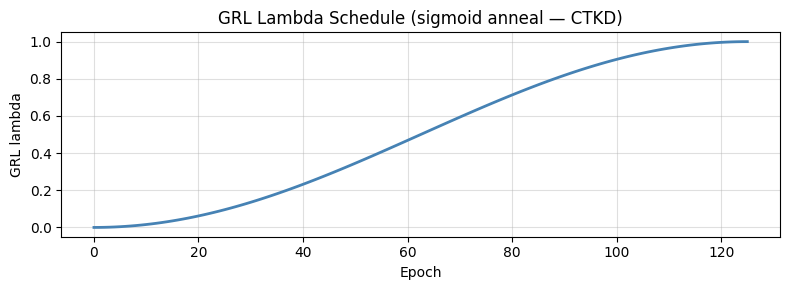

lambda at epoch   0 : 0.0000
lambda at epoch   31 : 0.1442
lambda at epoch   62 : 0.4937
lambda at epoch 125 : 1.0000


In [8]:
class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, grl_lambda):
        ctx.save_for_backward(torch.tensor(grl_lambda))
        return x.clone()

    @staticmethod
    def backward(ctx, grad_output):
        grl_lambda, = ctx.saved_tensors
        return -grl_lambda.item() * grad_output, None


def grad_reverse(x, grl_lambda):
    return GradientReversalFunction.apply(x, grl_lambda)


def compute_grl_lambda(epoch, total_epochs, lambda_max=GRL_LAMBDA_MAX):
    """Sigmoid-annealed GRL schedule from CTKD (Li et al., ECCV 2022)."""
    progress = min(epoch, total_epochs) / total_epochs

    lam = 0.0 + 0.5 * (lambda_max - 0.0) * (
        1 - np.cos(np.pi * progress)
    )

    return lam


ep_range = np.arange(0, EPOCHS + 1)
lambdas  = [compute_grl_lambda(e, EPOCHS) for e in ep_range]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ep_range, lambdas, color='steelblue', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('GRL lambda')
ax.set_title('GRL Lambda Schedule (sigmoid anneal — CTKD)')
ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

print(f'lambda at epoch   0 : {compute_grl_lambda(0,          EPOCHS):.4f}')
print(f'lambda at epoch  {EPOCHS//4:3d} : {compute_grl_lambda(EPOCHS//4,  EPOCHS):.4f}')
print(f'lambda at epoch  {EPOCHS//2:3d} : {compute_grl_lambda(EPOCHS//2,  EPOCHS):.4f}')
print(f'lambda at epoch {EPOCHS:3d} : {compute_grl_lambda(EPOCHS,     EPOCHS):.4f}')


## 6. Dual MLP Learnable Temperature Module

Each temperature is produced by a **three-layer MLP** (two hidden layers) that takes
the **batch-mean student logits** $\\bar{z}^S \\in \\mathbb{R}^C$ as input and outputs a
scalar $\\phi$, which is sigmoid-constrained to $[\\tau_{min}, \\tau_{max}]$:

$$\\tau = \\tau_{min} + (\\tau_{max} - \\tau_{min}) \\cdot \\sigma(\\phi), \\quad
\\phi = \\mathrm{MLP}(\\bar{z}^S)$$

Architecture per head (input dim $C$ = `NUM_CLASSES`):
```
Linear(C, H) → ReLU → Linear(H, H) → ReLU → Linear(H, 1)
```
where `H = MLP_HIDDEN_DIM`.

Using the **student logits** as input lets each MLP sense the student's current
prediction confidence and class distribution — much richer than a scalar epoch counter.
This means both temperatures adapt dynamically **per batch** based on what the student
actually knows right now, not just when in training it is.

Two **independent** MLP heads — `mlp_tckd` and `mlp_nckd` — let the two DKD components
learn distinct temperature responses to the same logit signal.

The GRL is applied to $\\phi$ before the sigmoid constraint, so both temperatures are
driven adversarially while the student minimises the distillation losses.

Both heads are initialised so that $\\tau \\approx 4.0$ at the start of training
(classical KD starting point).


In [9]:
class DualTemperatureModule(nn.Module):
    """
    Instance-level dual temperature module with Rank-4 calibration correction.

    Learns TWO separate temperatures per sample:
        - tau_tckd : for TCKD  (B,)
        - tau_nckd : for NCKD  (B,)

    Key improvement over batch-level variant:
        OLD: one tau for entire batch (batch-mean logits -> scalar)
        NEW: one tau PER SAMPLE      (per-sample logits -> (B,) vector)

    Each temperature is produced by a 3-layer MLP (two hidden layers):
        input  : student logits for one sample, shape (C,)
        layer1 : Linear(C, H) -> ReLU
        layer2 : Linear(H, H) -> ReLU
        output : Linear(H, 1) -> scalar phi_i
        constrained: tau_i = tau_min + (tau_max - tau_min) * sigmoid(phi_i)

    Rank 4 — Calibration-Corrected Temperature:
        A per-sample correction is added to phi_t *before* GRL and sigmoid:

            correction_i = delta * (1 - r_{t(x_i)})

        where r_c = accuracy_c / mean_confidence_c (precomputed, fixed).

        r_c < 1  ->  correction > 0  ->  phi_t pushed up  ->  higher tau_TCKD
                     ->  softer TCKD distribution  ->  dampened overconfident signal
        r_c ~= 1 ->  correction ~= 0 ->  no change, full distillation signal
        delta=0  ->  identical to original behaviour (correction disabled)

    GRL is applied to phi BEFORE sigmoid constraint.
    """
    def __init__(self, num_classes=NUM_CLASSES, tau_min=TAU_MIN, tau_max=TAU_MAX,
                 hidden_dim=MLP_HIDDEN_DIM):
        super().__init__()
        self.tau_min = tau_min
        self.tau_max = tau_max

        # ---------------- TCKD head ----------------
        self.mlp_tckd = nn.Sequential(
            nn.Linear(num_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        # ---------------- NCKD head ----------------
        self.mlp_nckd = nn.Sequential(
            nn.Linear(num_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

        # Initialise both heads so that tau ~= 4.0 at the start of training.
        init_ratio = (4.0 - tau_min) / (tau_max - tau_min)
        init_phi   = float(np.log(init_ratio / (1.0 - init_ratio)))  # inverse sigmoid

        for mlp in (self.mlp_tckd, self.mlp_nckd):
            for layer in mlp:
                if isinstance(layer, nn.Linear):
                    nn.init.zeros_(layer.weight)
                    nn.init.zeros_(layer.bias)
            nn.init.constant_(mlp[-1].bias, init_phi)

    def _constrain(self, phi):
        """Maps unconstrained phi -> [tau_min, tau_max]."""
        return self.tau_min + (self.tau_max - self.tau_min) * torch.sigmoid(phi)

    def _run_mlp_per_sample(self, mlp, logits):
        """
        Input:
            logits : (B, C)
        Output:
            phi    : (B,)
        """
        feat = logits.detach()          # (B, C) — detach: no grad to student
        phi  = mlp(feat).squeeze(1)     # (B,)
        return phi

    def tau_tckd(self, s_logits):
        """Logging utility: returns mean tau_tckd (no GRL). Expects s_logits (B, C)."""
        with torch.no_grad():
            phi_t = self._run_mlp_per_sample(self.mlp_tckd, s_logits)
            tau_t = self._constrain(phi_t)
        return tau_t.mean()

    def tau_nckd(self, s_logits):
        """Logging utility: returns mean tau_nckd (no GRL). Expects s_logits (B, C)."""
        with torch.no_grad():
            phi_n = self._run_mlp_per_sample(self.mlp_nckd, s_logits)
            tau_n = self._constrain(phi_n)
        return tau_n.mean()

    def forward(self, s_logits, grl_lambda, labels=None, class_calib_ratio=None, delta=0.0):
        """Returns (tau_tckd, tau_nckd) with GRL applied for adversarial update.

        Args:
            s_logits          : (B, C) student logits — MLP input (per sample)
            grl_lambda        : float — current GRL reversal strength
            labels            : (B,)  ground-truth class indices       [Rank 4]
            class_calib_ratio : (C,)  precomputed r_c tensor, on device [Rank 4]
            delta             : float — calibration correction strength  [Rank 4]

        Returns:
            tau_tckd : (B,)
            tau_nckd : (B,)
        """
        # -------------------------------------------------
        # Instance-level phi: one value per sample
        # -------------------------------------------------
        phi_t = self._run_mlp_per_sample(self.mlp_tckd, s_logits)  # (B,)
        phi_n = self._run_mlp_per_sample(self.mlp_nckd, s_logits)  # (B,)

        # ── Rank 4: per-sample calibration correction on phi_t ───────────────
        # Applied before GRL so the correction shifts the base temperature,
        # not the adversarial gradient. Detached so no gradient flows into r_c.
        if labels is not None and class_calib_ratio is not None and delta > 0.0:
            r_batch    = class_calib_ratio[labels]          # (B,) r_c per sample's GT class
            correction = delta * (1.0 - r_batch)            # (B,) per-sample correction
            phi_t      = phi_t + correction.detach()        # (B,) shifted phi_t

        # -------------------------------------------------
        # GRL — reverses gradients into each MLP
        # -------------------------------------------------
        phi_t = grad_reverse(phi_t, grl_lambda)
        phi_n = grad_reverse(phi_n, grl_lambda)

        # -------------------------------------------------
        # Constrain to tau range
        # -------------------------------------------------
        tau_t = self._constrain(phi_t)   # (B,)
        tau_n = self._constrain(phi_n)   # (B,)

        return tau_t, tau_n


# =========================================================
# Instantiate and verify
# =========================================================
temp_module = DualTemperatureModule(NUM_CLASSES, TAU_MIN, TAU_MAX, MLP_HIDDEN_DIM).to(DEVICE)

_dummy_logits = torch.zeros(4, NUM_CLASSES).to(DEVICE)   # simulate mini-batch of 4
tau_t, tau_n = temp_module(_dummy_logits, grl_lambda=1.0)

print('DualTemperatureModule (instance-wise, MLP, 2 hidden layers) initialised.')
print(f'  tau_tckd shape   : {tau_t.shape}  (one per sample)')
print(f'  tau_nckd shape   : {tau_n.shape}  (one per sample)')
print(f'  tau_tckd at init : {tau_t.mean().item():.4f}  (target: 4.0)')
print(f'  tau_nckd at init : {tau_n.mean().item():.4f}  (target: 4.0)')
print(f'  tau range        : [{TAU_MIN}, {TAU_MAX}]')
print(f'  MLP architecture : Linear({NUM_CLASSES}, {MLP_HIDDEN_DIM}) -> ReLU -> '
      f'Linear({MLP_HIDDEN_DIM}, {MLP_HIDDEN_DIM}) -> ReLU -> Linear({MLP_HIDDEN_DIM}, 1)')
total_temp_params = sum(p.numel() for p in temp_module.parameters())
print(f'  Trainable params : {total_temp_params}  '
      f'(mlp_tckd: {sum(p.numel() for p in temp_module.mlp_tckd.parameters())}  '
      f'mlp_nckd: {sum(p.numel() for p in temp_module.mlp_nckd.parameters())})')


DualTemperatureModule (instance-wise, MLP, 2 hidden layers) initialised.
  tau_tckd shape   : torch.Size([4])  (one per sample)
  tau_nckd shape   : torch.Size([4])  (one per sample)
  tau_tckd at init : 4.0000  (target: 4.0)
  tau_nckd at init : 4.0000  (target: 4.0)
  tau range        : [2.0, 10.0]
  MLP architecture : Linear(100, 64) -> ReLU -> Linear(64, 64) -> ReLU -> Linear(64, 1)
  Trainable params : 21378  (mlp_tckd: 10689  mlp_nckd: 10689)


## 7. DKD Loss with Dual Learnable Temperatures

Identical loss formulation to the original DKD+CTKD notebook.
TCKD uses binary-distribution BCE at $\tau_{TCKD}$; NCKD uses KL over non-target classes at $\tau_{NCKD}$.


In [10]:
class DKDDualTempLoss(nn.Module):
    """
    DKD loss with instance-level independently learnable temperatures for TCKD and NCKD.

    CE is computed via criterion_ce (label_smoothing=0.1) passed in from the caller,
    matching the retrained baseline where label-smoothed CE is used throughout.

    Args:
        alpha : weight on TCKD loss  (default 1.0)
        beta  : weight on NCKD loss  (default 8.0)

    Forward:
        s_logits    : (B, C) student logits
        t_logits    : (B, C) teacher logits  (no_grad expected from caller)
        labels      : (B,)   integer ground-truth labels
        tau_tckd    : (B,)   per-sample temperature for TCKD (with GRL applied)
        tau_nckd    : (B,)   per-sample temperature for NCKD (with GRL applied)
        criterion_ce: nn.CrossEntropyLoss(label_smoothing=0.1) -- passed in

    Returns:
        total_loss, tckd_loss (detached), nckd_loss (detached), ce_loss (detached)
    """

    def __init__(self, alpha=ALPHA, beta=BETA):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta

    @staticmethod
    def _split_logits(logits, labels):
        B, C    = logits.shape
        gt_mask = F.one_hot(labels, C).bool()
        tgt     = logits[gt_mask].unsqueeze(1)      # (B, 1)
        rest    = logits[~gt_mask].view(B, C - 1)   # (B, C-1)
        return tgt, rest

    def forward(self, s_logits, t_logits, labels, tau_tckd, tau_nckd, criterion_ce):
        # CHANGED: label-smoothed CE (was F.cross_entropy with no smoothing)
        ce_loss = criterion_ce(s_logits, labels)

        s_tgt, s_rest = self._split_logits(s_logits, labels)
        t_tgt, t_rest = self._split_logits(t_logits, labels)

        # Convert (B,) tau -> (B, 1) for broadcasting over logit dimension
        tau_tckd = tau_tckd.unsqueeze(1)   # (B, 1)
        tau_nckd = tau_nckd.unsqueeze(1)   # (B, 1)

        # -- TCKD: binary distribution BCE (per-sample temperature) -----------
        s_bin = torch.cat([s_tgt, s_rest.logsumexp(dim=1, keepdim=True)], dim=1)
        t_bin = torch.cat([t_tgt, t_rest.logsumexp(dim=1, keepdim=True)], dim=1)

        s_bin_prob = torch.softmax(s_bin / tau_tckd, dim=1)
        t_bin_prob = torch.softmax(t_bin / tau_tckd, dim=1)
        tckd_loss  = -(t_bin_prob * torch.log(s_bin_prob + 1e-8)).sum(dim=1).mean()

        # -- NCKD: KL over non-target classes (per-sample temperature) --------
        s_nckd    = F.log_softmax(s_rest / tau_nckd, dim=1)
        t_nckd    = F.softmax(t_rest    / tau_nckd, dim=1)
        nckd_loss = F.kl_div(s_nckd, t_nckd, reduction='batchmean')

        # total = CE + alpha*TCKD + beta*NCKD  (CE is label-smoothed)
        total = ce_loss + self.alpha * tckd_loss + self.beta * nckd_loss

        return total, tckd_loss.detach(), nckd_loss.detach(), ce_loss.detach()


# Label-smoothed CE -- used inside DKDDualTempLoss and logged separately
criterion_ce = nn.CrossEntropyLoss(label_smoothing=0.1)
criterion     = DKDDualTempLoss(alpha=ALPHA, beta=BETA)

print('DKDDualTempLoss instantiated (supports instance-level (B,) temperatures).')
print(f'  alpha (TCKD weight) : {criterion.alpha}')
print(f'  beta  (NCKD weight) : {criterion.beta}')
print(f'  CE    (label smooth): label_smoothing=0.1')


DKDDualTempLoss instantiated (supports instance-level (B,) temperatures).
  alpha (TCKD weight) : 1.0
  beta  (NCKD weight) : 8.0
  CE    (label smooth): label_smoothing=0.1


## 8. Optimiser and Scheduler

SGD + Nesterov, CosineAnnealingLR — identical to the retrained baseline notebook.
Temperature parameters in a separate param group with their own LR so they are
unaffected by the student's cosine decay.


In [11]:
student_params = list(student.parameters())
temp_params    = list(temp_module.parameters())  # includes both MLP heads

optimizer = torch.optim.SGD([
    {'params': student_params, 'lr': LR},
    {'params': temp_params,    'lr': LR_TEMP},
], momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, nesterov=True)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-4
)

print('Optimiser and scheduler configured.')
print(f'  Optimiser    : SGD (Nesterov)  student lr={LR}  temp lr={LR_TEMP}')
print(f'  Scheduler    : CosineAnnealingLR  T_max={EPOCHS}  eta_min=1e-4')
print(f'  WD           : {WEIGHT_DECAY}')
print(f'  Student params  : {sum(p.numel() for p in student_params)/1e6:.2f}M')
print(f'  Temp MLP params : {sum(p.numel() for p in temp_params)}')
print(f'    mlp_tckd      : {sum(p.numel() for p in temp_module.mlp_tckd.parameters())}')
print(f'    mlp_nckd      : {sum(p.numel() for p in temp_module.mlp_nckd.parameters())}')


Optimiser and scheduler configured.
  Optimiser    : SGD (Nesterov)  student lr=0.05  temp lr=0.001
  Scheduler    : CosineAnnealingLR  T_max=125  eta_min=1e-4
  WD           : 0.0001
  Student params  : 2.35M
  Temp MLP params : 21378
    mlp_tckd      : 10689
    mlp_nckd      : 10689


## 9. Evaluation Utility

In [12]:
@torch.no_grad()
def evaluate(model, loader, device):
    """Top-1 and Top-5 accuracy."""
    model.eval()
    top1_c = top5_c = total = 0
    for imgs, labels in tqdm(loader, desc='Eval', leave=False, dynamic_ncols=True):
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        top1_c += (logits.argmax(1) == labels).sum().item()
        top5_c += (logits.topk(5, dim=1).indices == labels.unsqueeze(1)).any(1).sum().item()
        total  += labels.size(0)
    return 100.0 * top1_c / total, 100.0 * top5_c / total

print('evaluate() ready -- returns (top1 %, top5 %).')


evaluate() ready -- returns (top1 %, top5 %).


## 10. Training Loop

In [13]:
def train_one_epoch(student, teacher, temp_module, criterion, criterion_ce,
                    optimizer, loader, grl_lambda, device, epoch, total_epochs,
                    class_calib_ratio=None, delta=0.0):
    """One epoch of DKD + dual-MLP-temp adversarial training. Returns dict of averaged metrics.

    Rank 4: if class_calib_ratio (C,) and delta>0 are supplied, a calibration
    correction is forwarded into temp_module to raise tau_TCKD for overconfident
    classes and leave well-calibrated classes unchanged.
    """
    student.train()
    teacher.eval()          # teacher always in eval mode
    for p in teacher.parameters():
        p.requires_grad_(False)   # ensure teacher params never accumulate grads
    temp_module.train()

    sums = dict(total=0., tckd=0., nckd=0., ce=0., correct=0, n=0)
    last_s_logits = None   # track for epoch-end logging
    pbar = tqdm(loader, desc=f'Ep {epoch:3d}/{total_epochs}', leave=False, dynamic_ncols=True)

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        B = imgs.size(0)

        with torch.no_grad():
            t_logits = teacher(imgs)

        optimizer.zero_grad()
        s_logits = student(imgs)

        # GRL disabled for first 5 epochs for stable warmup
        effective_lambda = grl_lambda if epoch > 5 else 0.0

        # MLP produces temperature conditioned on student logits (batch-mean)
        # Rank 4: calibration correction applied inside forward() when args provided
        tau_t, tau_n = temp_module(
            s_logits, effective_lambda,
            labels=labels, class_calib_ratio=class_calib_ratio, delta=delta,
        )

        total_loss, tckd_l, nckd_l, ce_l = criterion(
            s_logits, t_logits, labels, tau_t, tau_n, criterion_ce
        )
        total_loss.backward()
        optimizer.step()

        sums['total']   += total_loss.item() * B
        sums['tckd']    += tckd_l.item()     * B
        sums['nckd']    += nckd_l.item()     * B
        sums['ce']      += ce_l.item()        * B
        sums['correct'] += (s_logits.argmax(1) == labels).sum().item()
        sums['n']       += B
        last_s_logits    = s_logits.detach()   # save last batch for epoch-end logging

        pbar.set_postfix(
            loss=f'{total_loss.item():.3f}',
            tau_t=f'{tau_t.mean().item():.2f}',
            tau_n=f'{tau_n.mean().item():.2f}',
        )

    n = sums['n']
    return {
        'total_loss' : sums['total'] / n,
        'tckd_loss'  : sums['tckd'] / n,
        'nckd_loss'  : sums['nckd'] / n,
        'ce_loss'    : sums['ce']   / n,
        'train_acc'  : 100.0 * sums['correct'] / n,
        # log temps from last batch (no GRL)
        'tau_tckd'   : temp_module.tau_tckd(last_s_logits).item(),
        'tau_nckd'   : temp_module.tau_nckd(last_s_logits).item(),
        'grl_lambda' : grl_lambda,
    }

print('train_one_epoch() defined.')


train_one_epoch() defined.


## 11. Training Run

In [14]:
history = {
    'epoch': [], 'total_loss': [], 'tckd_loss': [], 'nckd_loss': [], 'ce_loss': [],
    'train_acc': [], 'test_top1': [], 'test_top5': [],
    'tau_tckd': [], 'tau_nckd': [], 'grl_lambda': [],
}

best_top1  = 0.0
best_epoch = 0

print('Starting DKD + Dual MLP Learnable Temperature training...')
print(f'  Epochs         : {EPOCHS}')
print(f'  alpha / beta   : {ALPHA} / {BETA}')
print(f'  tau range      : [{TAU_MIN}, {TAU_MAX}]')
print(f'  MLP hidden dim : {MLP_HIDDEN_DIM}  (per head)')
_init_logits = torch.zeros(4, NUM_CLASSES).to(DEVICE)
print(f'  Initial tau       : {temp_module.tau_tckd(_init_logits).item():.2f} (TCKD)  '
      f'{temp_module.tau_nckd(_init_logits).item():.2f} (NCKD)')
print(f'  CE smoothing   : 0.1')
print(f'  DELTA (calib)  : {DELTA}  (0.0 = disabled)')
print('-' * 90)

for epoch in range(1, EPOCHS + 1):
    grl_lambda = compute_grl_lambda(epoch, EPOCHS, GRL_LAMBDA_MAX)

    metrics = train_one_epoch(
        student, teacher, temp_module, criterion, criterion_ce,
        optimizer, train_loader, grl_lambda, DEVICE, epoch, EPOCHS,
        class_calib_ratio=class_calib_ratio,   # Rank 4
        delta=DELTA,                            # Rank 4
    )
    top1, top5 = evaluate(student, test_loader, DEVICE)
    scheduler.step()

    history['epoch'].append(epoch)
    history['total_loss'].append(metrics['total_loss'])
    history['tckd_loss'].append(metrics['tckd_loss'])
    history['nckd_loss'].append(metrics['nckd_loss'])
    history['ce_loss'].append(metrics['ce_loss'])
    history['train_acc'].append(metrics['train_acc'])
    history['test_top1'].append(top1)
    history['test_top5'].append(top5)
    history['tau_tckd'].append(metrics['tau_tckd'])
    history['tau_nckd'].append(metrics['tau_nckd'])
    history['grl_lambda'].append(grl_lambda)

    if top1 > best_top1:
        best_top1  = top1
        best_epoch = epoch
        torch.save({
            'state_dict'   : student.state_dict(),
            'temp_state'   : temp_module.state_dict(),
            'epoch'        : epoch,
            'top1'         : top1,
            'top5'         : top5,
            'tau_tckd'     : metrics['tau_tckd'],
            'tau_nckd'     : metrics['tau_nckd'],
            'alpha'        : ALPHA,
            'beta'         : BETA,
            'lr'           : LR,
            'wd'           : WEIGHT_DECAY,
            'label_smoothing': 0.1,
            'scheduler'    : 'CosineAnnealingLR',
            'mlp_hidden_dim': MLP_HIDDEN_DIM,
            'delta'        : DELTA,              # Rank 4
            'calib_ratio'  : class_calib_ratio.cpu(),  # Rank 4
        }, CKPT_DIR / 'b7_mobilenetv2_dkd_dual_mlp_temp_cifar100_cosine.pth')

    if epoch < 10 or epoch % 5 == 0 or epoch == EPOCHS:
        current_lr = scheduler.get_last_lr()[0]
        print(
            f'Ep {epoch:3d}/{EPOCHS} | '
            f'loss {metrics["total_loss"]:6.3f} '
            f'(tckd {metrics["tckd_loss"]:5.3f} | nckd {metrics["nckd_loss"]:5.3f} | ce {metrics["ce_loss"]:5.3f}) | '
            f'train {metrics["train_acc"]:5.2f}% | '
            f'test top1 {top1:5.2f}% top5 {top5:5.2f}% | '
            f'tau_t {metrics["tau_tckd"]:4.2f} tau_n {metrics["tau_nckd"]:4.2f} | '
            f'lambda {grl_lambda:.3f} | lr {current_lr:.5f}'
            + (' [*]' if top1 == best_top1 else '')
        )

print('-' * 90)
print(f'Training complete.')
print(f'  Best test Top-1 : {best_top1:.2f}%  (epoch {best_epoch})')
print(f'  Checkpoint      : b7_mobilenetv2_dkd_dual_mlp_temp_cifar100_cosine.pth')
print(f'  tau_TCKD at best epoch : {history["tau_tckd"][best_epoch-1]:.4f}')
print(f'  tau_NCKD at best epoch : {history["tau_nckd"][best_epoch-1]:.4f}')
print(f'  Final tau_TCKD  : {history["tau_tckd"][-1]:.4f}')
print(f'  Final tau_NCKD  : {history["tau_nckd"][-1]:.4f}')
print(f'  Final divergence: {history["tau_tckd"][-1] - history["tau_nckd"][-1]:+.4f}')

with open(CKPT_DIR / 'dkd_dual_mlp_temp_training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f'Training history saved.')


Starting DKD + Dual MLP Learnable Temperature training...
  Epochs         : 125
  alpha / beta   : 1.0 / 8.0
  tau range      : [2.0, 10.0]
  MLP hidden dim : 64  (per head)
  Initial tau       : 4.00 (TCKD)  4.00 (NCKD)
  CE smoothing   : 0.1
  DELTA (calib)  : 1.0  (0.0 = disabled)
------------------------------------------------------------------------------------------


Ep   1/125 | loss  6.739 (tckd 1.041 | nckd 0.195 | ce 4.138) | train  8.09% | test top1 15.29% top5 40.21% | tau_t 4.00 tau_n 4.00 | lambda 0.000 | lr 0.04999 [*]


Ep   2/125 | loss  6.107 (tckd 0.979 | nckd 0.176 | ce 3.722) | train 15.60% | test top1 20.25% top5 50.01% | tau_t 4.00 tau_n 4.00 | lambda 0.001 | lr 0.04997 [*]


Ep   3/125 | loss  5.775 (tckd 0.947 | nckd 0.166 | ce 3.503) | train 20.48% | test top1 24.49% top5 54.30% | tau_t 4.00 tau_n 4.00 | lambda 0.001 | lr 0.04993 [*]


Ep   4/125 | loss  5.491 (tckd 0.918 | nckd 0.157 | ce 3.320) | train 24.68% | test top1 29.99% top5 61.75% | tau_t 4.00 tau_n 4.00 | lambda 0.003 | lr 0.04987 [*]


...

Ep 105/125 | loss  3.557 (tckd 0.645 | nckd 0.187 | ce 1.417) | train 87.33% | test top1 72.93% top5 93.14% | tau_t 6.71 tau_n 2.01 | lambda 0.938 | lr 0.00319


Ep 110/125 | loss  3.530 (tckd 0.645 | nckd 0.184 | ce 1.409) | train 87.67% | test top1 73.17% top5 93.30% | tau_t 6.83 tau_n 2.01 | lambda 0.965 | lr 0.00185


Ep 115/125 | loss  3.494 (tckd 0.646 | nckd 0.181 | ce 1.399) | train 88.32% | test top1 73.28% top5 93.17% | tau_t 6.93 tau_n 2.01 | lambda 0.984 | lr 0.00088


Ep 120/125 | loss  3.484 (tckd 0.647 | nckd 0.180 | ce 1.400) | train 88.40% | test top1 73.30% top5 93.14% | tau_t 7.02 tau_n 2.01 | lambda 0.996 | lr 0.00030


Ep 125/125 | loss  3.480 (tckd 0.647 | nckd 0.179 | ce 1.400) | train 88.29% | test top1 73.09% top5 93.18% | tau_t 7.09 tau_n 2.01 | lambda 1.000 | lr 0.00010
------------------------------------------------------------------------------------------
Training complete.
  Best test Top-1 : 73.36%  (epoch 108)
  Checkpoint      : b7_mobilenetv2_dkd_dual_mlp_temp_cifar100_cosine.pth
  tau_TCKD at best epoch : 6.7881
  tau_NCKD at best epoch : 2.0075
  Final tau_TCKD  : 7.0943
  Final tau_NCKD  : 2.0070
  Final divergence: +5.0873
Training history saved.


## 12. Training Visualisations

### 12.1 Accuracy and Loss Curves

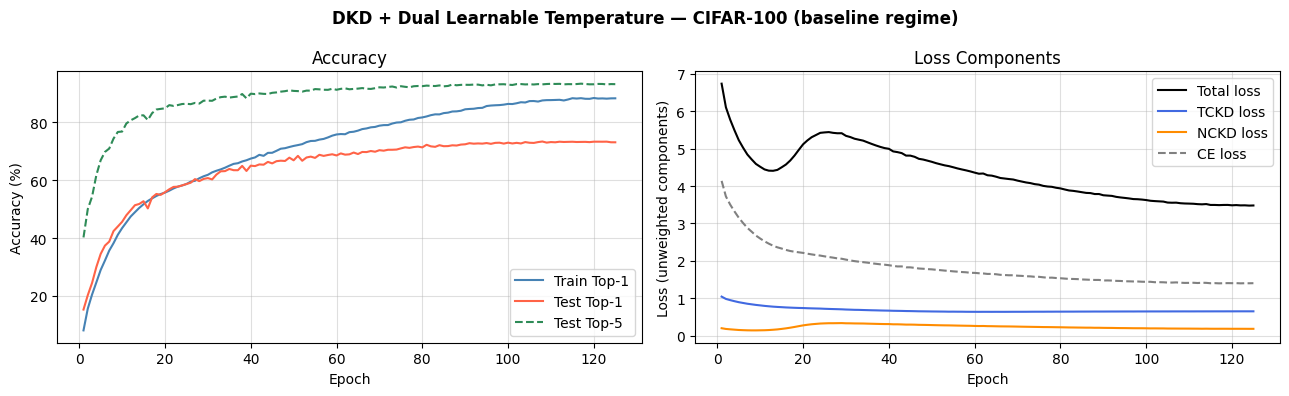

Curve data saved -> checkpoints/dkd_dual_temp_accuracy_loss_curves.json


In [15]:
ep = history['epoch']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('DKD + Dual Learnable Temperature — CIFAR-100 (baseline regime)', fontweight='bold')

axes[0].plot(ep, history['train_acc'],  label='Train Top-1', color='steelblue')
axes[0].plot(ep, history['test_top1'],  label='Test Top-1',  color='tomato')
axes[0].plot(ep, history['test_top5'],  label='Test Top-5',  color='seagreen', linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(ep, history['total_loss'], label='Total loss',  color='black')
axes[1].plot(ep, history['tckd_loss'],  label='TCKD loss',   color='royalblue')
axes[1].plot(ep, history['nckd_loss'],  label='NCKD loss',   color='darkorange')
axes[1].plot(ep, history['ce_loss'],    label='CE loss',     color='gray', linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss (unweighted components)')
axes[1].set_title('Loss Components'); axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout(); plt.show()

with open(CKPT_DIR / 'dkd_dual_temp_accuracy_loss_curves.json', 'w') as f:
    json.dump({'epoch': history['epoch'], 'train_acc': history['train_acc'],
               'test_top1': history['test_top1'], 'test_top5': history['test_top5'],
               'total_loss': history['total_loss'], 'tckd_loss': history['tckd_loss'],
               'nckd_loss': history['nckd_loss'], 'ce_loss': history['ce_loss']}, f, indent=2)
print(f'Curve data saved -> {CKPT_DIR / "dkd_dual_temp_accuracy_loss_curves.json"}')


### 12.2 Temperature Curriculum

The central diagnostic: do $\tau_{TCKD}$ and $\tau_{NCKD}$ evolve differently?

- If they **diverge**: the two DKD components require different temperature scales, validating the dual-temperature design.
- If $\tau_{TCKD}$ rises and $\tau_{NCKD}$ falls (or vice versa): the GRL is finding asymmetric optima.
- If they stay flat: consider increasing `LR_TEMP` or `GRL_LAMBDA_MAX`.


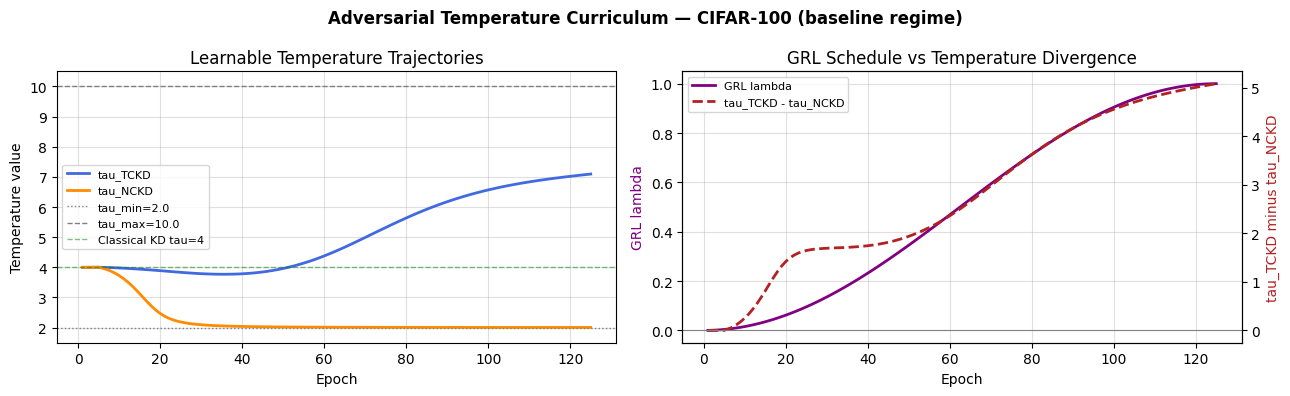

Temperature curriculum interpretation:
  Initial tau_TCKD : ~4.00  ->  Final: 7.094
  Initial tau_NCKD : ~4.00  ->  Final: 2.007
  Final divergence (TCKD - NCKD) : +5.087
Temperature data saved -> checkpoints/dkd_dual_temp_temperature_curriculum.json


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Adversarial Temperature Curriculum — CIFAR-100 (baseline regime)', fontweight='bold')

axes[0].plot(ep, history['tau_tckd'], label='tau_TCKD', color='royalblue', linewidth=2)
axes[0].plot(ep, history['tau_nckd'], label='tau_NCKD', color='darkorange', linewidth=2)
axes[0].axhline(TAU_MIN, color='gray', linestyle=':', linewidth=1, label=f'tau_min={TAU_MIN}')
axes[0].axhline(TAU_MAX, color='gray', linestyle='--', linewidth=1, label=f'tau_max={TAU_MAX}')
axes[0].axhline(4.0, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Classical KD tau=4')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Temperature value')
axes[0].set_title('Learnable Temperature Trajectories')
axes[0].set_ylim(TAU_MIN - 0.5, TAU_MAX + 0.5)
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.4)

ax2  = axes[1]
ax2b = ax2.twinx()
tau_diff = [t - n for t, n in zip(history['tau_tckd'], history['tau_nckd'])]
ax2.plot(ep,  history['grl_lambda'], color='purple',   linewidth=2, label='GRL lambda')
ax2b.plot(ep, tau_diff,              color='firebrick', linewidth=2, linestyle='--', label='tau_TCKD - tau_NCKD')
ax2b.axhline(0, color='gray', linewidth=0.8)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('GRL lambda', color='purple')
ax2b.set_ylabel('tau_TCKD minus tau_NCKD', color='firebrick')
ax2.set_title('GRL Schedule vs Temperature Divergence')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax2.grid(True, alpha=0.4)

plt.tight_layout(); plt.show()

print('Temperature curriculum interpretation:')
print(f'  Initial tau_TCKD : ~4.00  ->  Final: {history["tau_tckd"][-1]:.3f}')
print(f'  Initial tau_NCKD : ~4.00  ->  Final: {history["tau_nckd"][-1]:.3f}')
print(f'  Final divergence (TCKD - NCKD) : {history["tau_tckd"][-1] - history["tau_nckd"][-1]:+.3f}')

with open(CKPT_DIR / 'dkd_dual_temp_temperature_curriculum.json', 'w') as f:
    json.dump({'epoch': history['epoch'], 'tau_tckd': history['tau_tckd'],
               'tau_nckd': history['tau_nckd'], 'tau_diff': tau_diff,
               'grl_lambda': history['grl_lambda'],
               'tau_min': float(TAU_MIN), 'tau_max': float(TAU_MAX)}, f, indent=2)
print(f'Temperature data saved -> {CKPT_DIR / "dkd_dual_temp_temperature_curriculum.json"}')


## 13. Results Summary

In [17]:
baseline_results = {
    'B1 ResNet-18 Teacher'          : {'top1': None, 'note': 'Teacher ceiling'},
    'B2 MobileNetV2 Vanilla'        : {'top1': None, 'note': 'Student w/o KD (retrained)'},
    'B3 MobileNetV2 + Classical KD' : {'top1': None, 'note': 'Primary baseline (retrained)'},
    'B4 DKD (cosine)'               : {'top1': None, 'note': 'DKD fixed tau, cosine regime'},
    'B5 CTKD (cosine)'              : {'top1': None, 'note': 'CTKD learnable tau, cosine regime'},
}

for ckpt_file, key in [
    ('b1_resnet18_teacher_cifar100.pth',            'B1 ResNet-18 Teacher'),
    ('b2_mobilenetv2_vanilla_cifar100.pth',         'B2 MobileNetV2 Vanilla'),
    ('b3_mobilenetv2_kd_cifar100.pth',              'B3 MobileNetV2 + Classical KD'),
    ('b4_mobilenetv2_dkd_cifar100_cosine.pth',      'B4 DKD (cosine)'),
    ('b5_mobilenetv2_ctkd_cifar100_cosine.pth',     'B5 CTKD (cosine)'),
]:
    path = CKPT_DIR / ckpt_file
    if path.exists():
        ckpt = torch.load(path, map_location='cpu')
        t1 = ckpt.get('top1', ckpt.get('val_top1', None))
        if t1:
            baseline_results[key]['top1'] = round(t1, 2)

rows = [{'Model': k, 'Top-1 (%)': v['top1'], 'Note': v['note']}
        for k, v in baseline_results.items()]
rows.append({
    'Model'     : 'B7 DKD + Dual MLP Temp, cosine (ours)',
    'Top-1 (%)' : round(best_top1, 2),
    'Note'      : (f'Best epoch {best_epoch}  |  '
                   f'tau_TCKD={history["tau_tckd"][best_epoch-1]:.2f}  '
                   f'tau_NCKD={history["tau_nckd"][best_epoch-1]:.2f}  '
                   f'label_smooth=0.1'),
})

df = pd.DataFrame(rows)
print('=' * 80)
print('CIFAR-100 RESULTS — DKD + DUAL LEARNABLE TEMPERATURES (COSINE REGIME)')
print('=' * 80)
print(df.to_string(index=False))
print('=' * 80)

b3_top1 = baseline_results['B3 MobileNetV2 + Classical KD']['top1']
if b3_top1 is not None:
    print(f'\nGain vs classical KD (B6 - B3): {best_top1 - b3_top1:+.2f}%')

with open(CKPT_DIR / 'dkd_dual_mlp_temp_results_summary.json', 'w') as f:
    json.dump({'baseline_results': baseline_results,
               'best': {'top1': round(best_top1, 2),
                        'top5': round(history['test_top5'][best_epoch-1], 2),
                        'epoch': best_epoch,
                        'tau_tckd': history['tau_tckd'][best_epoch-1],
                        'tau_nckd': history['tau_nckd'][best_epoch-1]}}, f, indent=2)
print(f'Results saved -> {CKPT_DIR / "dkd_dual_mlp_temp_results_summary.json"}')


CIFAR-100 RESULTS — DKD + DUAL LEARNABLE TEMPERATURES (COSINE REGIME)
                                Model  Top-1 (%)                                                              Note
                 B1 ResNet-18 Teacher        NaN                                                   Teacher ceiling
               B2 MobileNetV2 Vanilla        NaN                                        Student w/o KD (retrained)
        B3 MobileNetV2 + Classical KD        NaN                                      Primary baseline (retrained)
                      B4 DKD (cosine)        NaN                                      DKD fixed tau, cosine regime
                     B5 CTKD (cosine)        NaN                                 CTKD learnable tau, cosine regime
B7 DKD + Dual MLP Temp, cosine (ours)      73.36 Best epoch 108  |  tau_TCKD=6.79  tau_NCKD=2.01  label_smooth=0.1
Results saved -> checkpoints/dkd_dual_mlp_temp_results_summary.json


## 14. Full Training History Table

In [18]:
df_hist = pd.DataFrame({
    'Epoch'      : history['epoch'],
    'Total Loss' : [f'{v:.4f}' for v in history['total_loss']],
    'TCKD Loss'  : [f'{v:.4f}' for v in history['tckd_loss']],
    'NCKD Loss'  : [f'{v:.4f}' for v in history['nckd_loss']],
    'CE Loss'    : [f'{v:.4f}' for v in history['ce_loss']],
    'Train Acc'  : [f'{v:.2f}%' for v in history['train_acc']],
    'Test Top-1' : [f'{v:.2f}%' for v in history['test_top1']],
    'Test Top-5' : [f'{v:.2f}%' for v in history['test_top5']],
    'tau_TCKD'   : [f'{v:.3f}' for v in history['tau_tckd']],
    'tau_NCKD'   : [f'{v:.3f}' for v in history['tau_nckd']],
    'GRL lambda' : [f'{v:.3f}' for v in history['grl_lambda']],
})
print(df_hist.to_string(index=False))

with open(CKPT_DIR / 'dkd_dual_temp_epoch_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f'\nEpoch-by-epoch history saved -> {CKPT_DIR / "dkd_dual_temp_epoch_history.json"}')


 Epoch Total Loss TCKD Loss NCKD Loss CE Loss Train Acc Test Top-1 Test Top-5 tau_TCKD tau_NCKD GRL lambda
     1     6.7388    1.0406    0.1951  4.1376     8.09%     15.29%     40.21%    4.001    4.001      0.000
     2     6.1068    0.9793    0.1757  3.7216    15.60%     20.25%     50.01%    4.001    4.001      0.001
     3     5.7753    0.9468    0.1657  3.5026    20.48%     24.49%     54.30%    4.002    4.002      0.001
     4     5.4912    0.9181    0.1566  3.3201    24.68%     29.99%     61.75%    4.003    4.003      0.003
     5     5.2273    0.8918    0.1481  3.1511    28.95%     34.49%     66.87%    4.003    4.003      0.004
     6     5.0269    0.8710    0.1432  3.0105    32.22%     37.38%     69.76%    4.000    3.970      0.006
     7     4.8438    0.8504    0.1392  2.8801    35.66%     38.77%     70.93%    3.996    3.927      0.008
     8     4.7129    0.8346    0.1375  2.7787    38.22%     42.40%     74.36%    3.991    3.873      0.010
     9     4.5915    0.8188    0.1373